<a href="https://colab.research.google.com/github/PRAJEENS2024/prajeen-codeboosters-2026/blob/main/Day%203/Day3_MiniProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
API_KEY = '84ea70af0c21ee26293a76457645dc4f' # api key
BASE_URL = 'https://api.openweathermap.org/data/2.5/weather'
CITIES = ['Mumbai','Delhi','Bangalore','Chennai','Hyderabad','Kolkata','Pune','Jaipur','Coimbatore','America','Balangir','Africa']
print(f'API configured for {len(CITIES)} cities')
print(f'Cities:{CITIES}')
print(f'\nIMPORTANT: Replace your YOUR_API_KEY_HERE with your actual key before running')

API configured for 12 cities
Cities:['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Hyderabad', 'Kolkata', 'Pune', 'Jaipur', 'Coimbatore', 'America', 'Balangir', 'Africa']

IMPORTANT: Replace your YOUR_API_KEY_HERE with your actual key before running


CALLING weather API..
Fetching:Mumbai...32.0C, Haze
Fetching:Delhi...30.1C, Rain
Fetching:Bangalore...30.6C, Clouds
Fetching:Chennai...33.0C, Clouds
Fetching:Hyderabad...37.2C, Clouds
Fetching:Kolkata...25.0C, Haze
Fetching:Pune...33.6C, Clear
Fetching:Jaipur...39.6C, Dust
Fetching:Coimbatore...30.9C, Clouds
Fetching:America...18.6C, Clouds
Fetching:Balangir...34.8C, Clouds
Fetching:Africa...33.1C, Clouds

Successfully fetched:12/12 cities


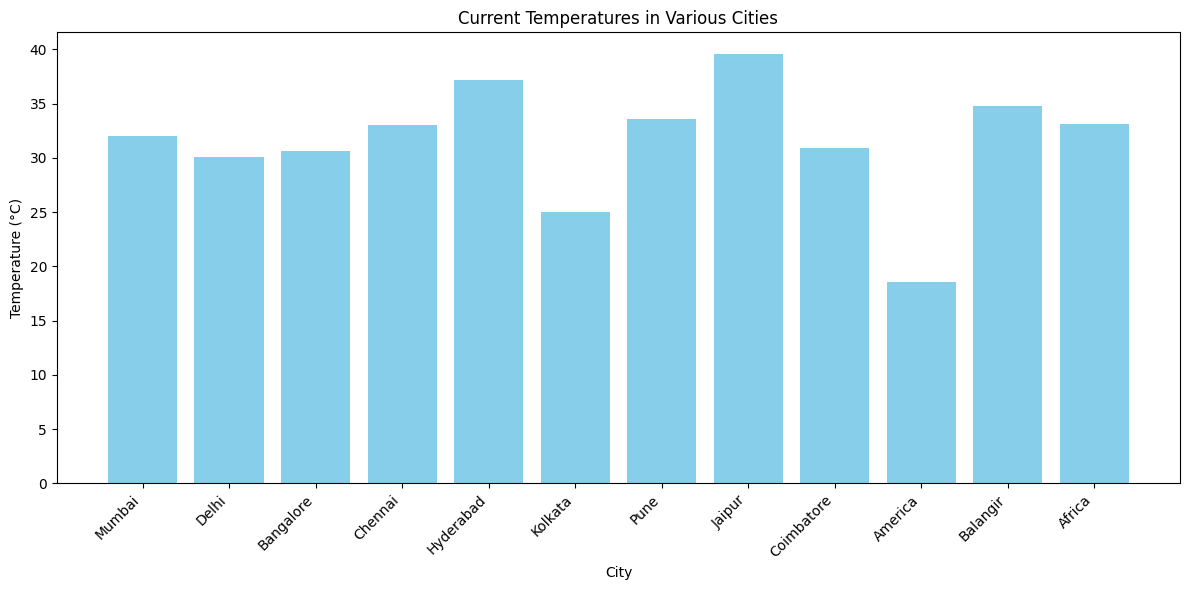


Weather Data Table:
          city  temperature  feels_like  humidity  pressure  wind_speed  \
0       Mumbai         32.0        37.7        62      1008        4.63   
1        Delhi         30.1        34.2        66      1000        6.69   
2    Bangalore         30.6        33.5        58      1009        3.60   
3      Chennai         33.0        40.0        65      1005        5.66   
4    Hyderabad         37.2        37.5        28      1005        5.14   
5      Kolkata         25.0        25.8        88      1004        2.06   
6         Pune         33.6        32.7        30      1008        6.62   
7       Jaipur         39.6        40.1        24       999        3.60   
8   Coimbatore         30.9        34.1        58      1008        3.60   
9      America         18.6        18.0        56      1011        1.62   
10    Balangir         34.8        34.4        30      1001        7.24   
11      Africa         33.1        33.7        39      1010        4.06   

   

In [2]:
import requests
import matplotlib.pyplot as plt
import pandas as pd

def fetch_weather(city, api_key):

  params = {
      'q' : city,
      'appid' :api_key,
      'units': 'metric'
  }
  try:
    response = requests.get(BASE_URL, params=params, timeout = 10)

    if response.status_code == 200:
      data = response.json()

      return{
          'city':city,
          'temperature':round(data['main']['temp'],1),
          'feels_like':round(data['main']['feels_like'],1),
          'humidity':data['main']['humidity'], # Added humidity
          'pressure':data['main']['pressure'], # Added pressure
          'wind_speed':data['wind']['speed'],
          'condition': data['weather'][0]['main'].title(),
          'visibility':data.get('visibility',0)
      }
    else:
        print(f'ERROR {response.status_code}) for {city} : {response.json().get("message")}')
  except requests.exceptions.ConnectionError:
    print(f'CONNECTION ERROR for {city} - check internet connection')
  return None # Explicitly return None on error


print("CALLING weather API..")
weather_records = []

for city in CITIES:
  print(f'Fetching:{city}...', end ='')
  record = fetch_weather(city, API_KEY)
  if record:
    weather_records.append(record)
    print(f'{record["temperature"]}C, {record["condition"]}')
  else:
    print('FAILED')
print(f'\nSuccessfully fetched:{len(weather_records)}/{len(CITIES)} cities')

# Create a Matplotlib project

# Extract data for plotting
cities_plot = [record['city'] for record in weather_records]
temperatures_plot = [record['temperature'] for record in weather_records]

# Create the bar chart
plt.figure(figsize=(12, 6))
plt.bar(cities_plot, temperatures_plot, color='skyblue')
plt.xlabel('City')
plt.ylabel('Temperature (°C)')
plt.title('Current Temperatures in Various Cities')
plt.xticks(rotation=45, ha='right') # Rotate city names for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

# Display data using pandas
df_weather = pd.DataFrame(weather_records)
print("\nWeather Data Table:")
print(df_weather[['city', 'temperature', 'feels_like', 'humidity', 'pressure', 'wind_speed', 'condition', 'visibility']])
